In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Olympics_Cleaned_with_Pivot.xlsx to Olympics_Cleaned_with_Pivot.xlsx


In [ ]:
# Step1:Import Libraries And Load Dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_excel("Olympics_Cleaned_with_Pivot.xlsx", sheet_name="Cleaned_Data")
df.head()

,City,Year,Sport,Discipline,Event,Athlete,Gender,Country,Medal,Gold,Silver,Bronze
0,Athens,2004,Aquatics,Diving,3m springboard,"DESPATIE, Alexandre",Men,Canada,Silver,0,1,0
1,Athens,2004,Aquatics,Diving,3m springboard,"SAUTIN, Dmitry",Men,Russia,Bronze,0,0,1
2,Athens,2004,Aquatics,Diving,3m springboard,"PAKHALINA, Ioulia",Women,Russia,Bronze,0,0,1
3,Athens,2004,Aquatics,Diving,synchronized diving 3m springboard,"NEWBERY, Robert",Men,Australia,Bronze,0,0,1
4,Athens,2004,Aquatics,Diving,synchronized diving 3m springboard,"BIMIS, Thomas",Men,Greece,Gold,1,0,0


In [ ]:
# Step 2:Exploratory Data Analysis
print("Dataset Shape:", df.shape)
print("\nSummary Statistics:\n")
print(df.describe(include="all"))
medal_counts = df["Medal"].value_counts()
print("\nMedal counts:\n", medal_counts)

Dataset Shape: (15316, 12)

Summary Statistics:

           City          Year     Sport Discipline   Event          Athlete  \
count     15316  15316.000000     15316      15316   15316            15316   
unique        9           NaN        28         41     293            11337   
top     Beijing           NaN  Aquatics  Athletics  hockey  PHELPS, Michael   
freq       2042           NaN      2210       1523     817               16   
mean        NaN   1993.620789       NaN        NaN     NaN              NaN   
std         NaN     10.159851       NaN        NaN     NaN              NaN   
min         NaN   1976.000000       NaN        NaN     NaN              NaN   
25%         NaN   1984.000000       NaN        NaN     NaN              NaN   
50%         NaN   1996.000000       NaN        NaN     NaN              NaN   
75%         NaN   2004.000000       NaN        NaN     NaN              NaN   
max         NaN   2008.000000       NaN        NaN     NaN              NaN   

  

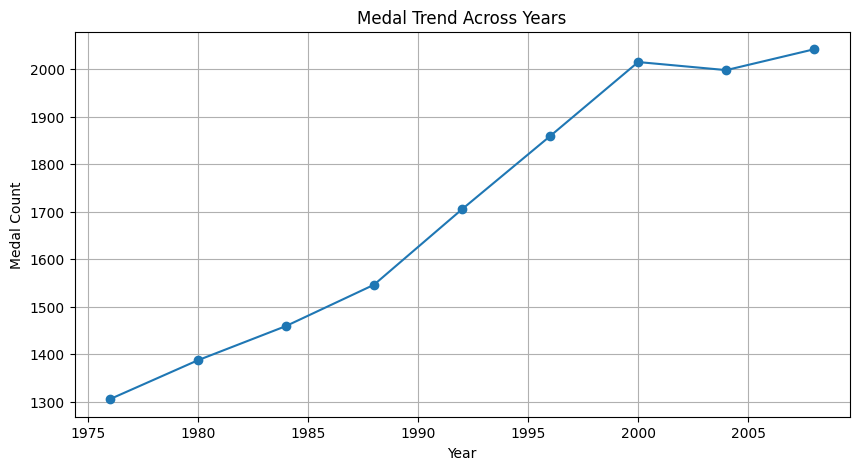

In [ ]:
# Step 3: Trend of medals across years
medals_per_year = df.groupby("Year").size()
plt.figure(figsize=(10,5))
plt.plot(medals_per_year.index, medals_per_year.values, marker='o')
plt.title("Medal Trend Across Years")
plt.xlabel("Year")
plt.ylabel("Medal Count")
plt.grid(True)
plt.show()

/tmp/ipython-input-2986194765.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


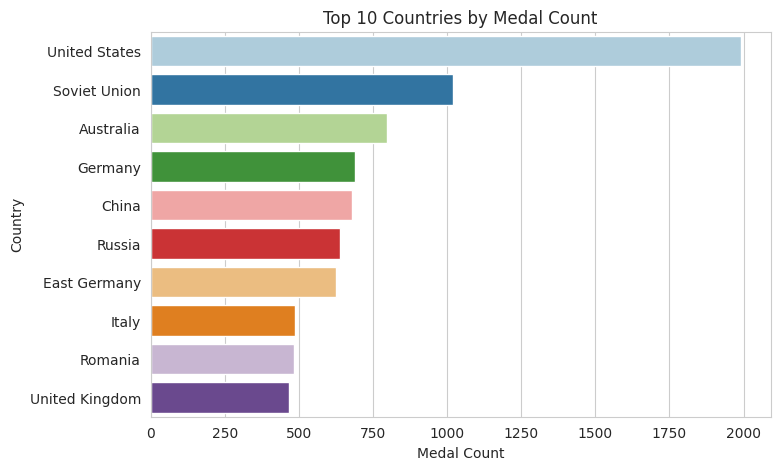

In [ ]:
# Step 4: Top Countries & Athletes
# Top 10 countries by medals
top_countries = df["Country"].value_counts().head(10)
plt.figure(figsize=(8,5))
sns.set_style("whitegrid")
sns.barplot(
   x=top_countries.values, y=top_countries.index, palette="Paired"
)
plt.title("Top 10 Countries by Medal Count")
plt.xlabel("Medal Count")
plt.ylabel("Country")
plt.show()

/tmp/ipython-input-33606902.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


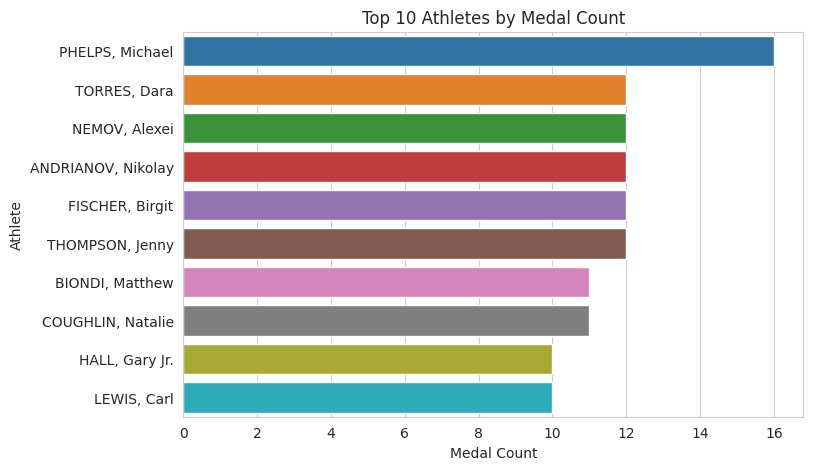

In [ ]:
# Top 10 Athletes
top_athletes = df["Athlete"].value_counts().head(10)
plt.figure(figsize=(8,5))
sns.set_style("whitegrid")
sns.barplot(
    x=top_athletes.values,
    y=top_athletes.index,
    palette="tab10"
)
plt.title("Top 10 Athletes by Medal Count")
plt.xlabel("Medal Count")
plt.ylabel("Athlete")
plt.show()

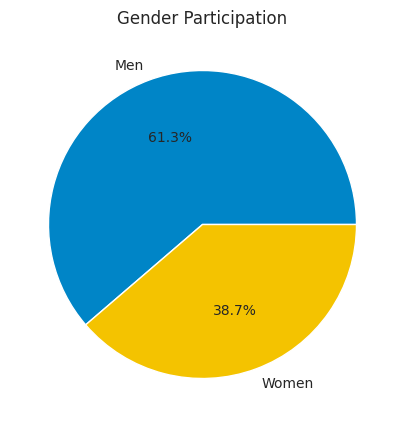

In [ ]:
# Step 5: Visualize Gender Participation
gender_counts = df["Gender"].value_counts()
olympic_colors = ["#0085C7", "#F4C300"]
plt.figure(figsize=(5,5))
plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    colors=olympic_colors
)
plt.title("Gender Participation")
plt.show()

/tmp/ipython-input-1733105022.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


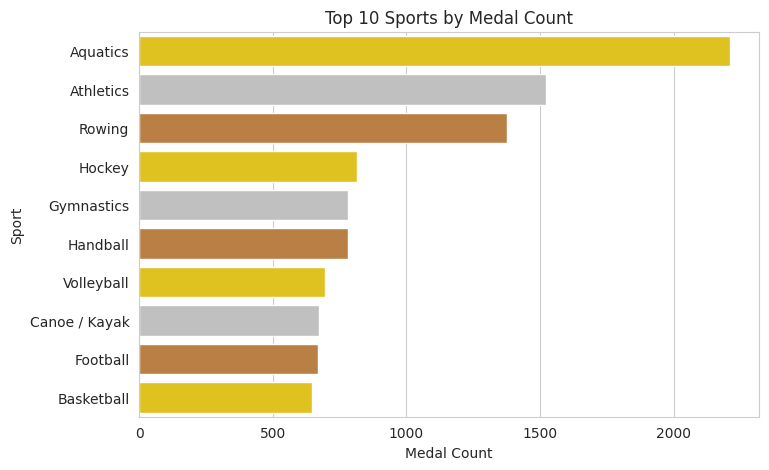

In [ ]:
# Step 6: Medals by Sport (Top 10 Sports)
top_sports = df["Sport"].value_counts().head(10)
# Medal color palette (Gold, Silver, Bronze)
medal_palette = ["#FFD700", "#C0C0C0", "#CD7F32", "#FFD700", "#C0C0C0",
                 "#CD7F32", "#FFD700", "#C0C0C0", "#CD7F32", "#FFD700"]
plt.figure(figsize=(8,5))
sns.barplot(
    x=top_sports.values,
    y=top_sports.index,
    palette=medal_palette
)
plt.title("Top 10 Sports by Medal Count")
plt.xlabel("Medal Count")
plt.ylabel("Sport")
plt.show()

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Olympics_Cleaned_with_Pivot.xlsx to Olympics_Cleaned_with_Pivot.xlsx


In [ ]:
# Prediction ML Model
# Step 7: Prepare Data
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

# Load dataset
df = pd.read_excel("Olympics_Cleaned_with_Pivot.xlsx", sheet_name="Cleaned_Data")

# Create target: 1 = Gold Medal, 0 = Not Gold
df["IsGold"] = df["Gold"].apply(lambda x: 1 if x > 0 else 0)

# Select features
features = ["Athlete", "Country", "Sport", "Gender", "Year"]
model_df = df[features + ["IsGold"]].copy()

# Encode categorical columns
le = LabelEncoder()
for col in ["Athlete", "Country", "Sport", "Gender"]:
    model_df[col] = le.fit_transform(model_df[col])

# Split data
X = model_df.drop("IsGold", axis=1)
y = model_df["IsGold"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
# Train a Balanced Logistic Regression Model
model = LogisticRegression(max_iter=300, class_weight="balanced")
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]   # probability for Power BI

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)


Model Accuracy: 51.08 %

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.51      0.58      2048
           1       0.34      0.52      0.41      1016

    accuracy                           0.51      3064
   macro avg       0.51      0.51      0.50      3064
weighted avg       0.57      0.51      0.53      3064


Confusion Matrix:
[[1037 1011]
 [ 488  528]]


In [ ]:
# Step 8 : Feature Importance (absolute logistic weights)
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.coef_[0]
})


In [ ]:
# Step 9 : Create prediction output dataset
output = pd.DataFrame({
    "Athlete": df.loc[X_test.index, "Athlete"],
    "Country": df.loc[X_test.index, "Country"],
    "Sport": df.loc[X_test.index, "Sport"],
    "Gender": df.loc[X_test.index, "Gender"],
    "Year": df.loc[X_test.index, "Year"],
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability": y_prob,
})

In [ ]:
# Step 10 : Export to CSV
output.to_csv("Olympics_ML_Predictions.csv", index=False)

print("\nCSV Exported Successfully!")


CSV Exported Successfully!


In [8]:
from google.colab import files
files.download("Olympics_ML_Predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
})
importance_df.to_csv("Feature_Importance.csv", index=False)


In [ ]:
from google.colab import files
files.download("Feature_Importance.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>